# The Three Claim-Matchers: Journalism, Peer Review, Patents

**2026-07-11 · claim-verification / claim-matching program wrap-up**

Three domains where we built the same instrument — *extract claims from a document, retrieve evidence, and judge whether the evidence supports/discloses/anticipates each claim* — and raced it against real outcomes. This notebook consolidates everything learned: the claim-processing pipeline per domain, instrument-validity evidence, final numbers, corrections/retractions, and the cross-domain synthesis.

**Embedded visual companion:** §3.4 contains a self-contained HTML/CSS representation of the patent retrieval process; it survives normal notebook-to-HTML export.

---
## The shared instrument shape

All three matchers converged on the same five-stage pipeline (the patents version came first; journalism and peer review are its ports):

1. **Claim extraction** — decompose the source document into atomic, checkable claims (news head → claims; abstract → 2–5 typed claims; patent claim → elements).
2. **Evidence pool construction** — the searchable universe (article body passages; subtractive paper body; K=8 candidate prior-art refs).
3. **Retrieval / localization** — put candidate passages in front of the judge (top-k chunks; top-8 body passages; two-stage span localization).
4. **Verification verdict** — LLM judge, per (claim × evidence): `FULL/PARTIAL/NONE`, `SOURCED/ASSERTED_ONLY/NOT_FOUND`, `discloses + verbatim spans`.
5. **Validity controls** — *every* batch: blinded known-label anchors, mismatched-document placebos, planted corruptions (number/entity swaps, planted SELF and foreign refs).

**Design rules the program earned** (each one paid for by a bug or a retraction):
- Blinded anchors in every judging batch; mismatched placebo arms (expect `NOT_FOUND`/`NONE`).
- Planted positive controls separate *instrument blindness* from *corpus range-restriction*.
- Any matched-vs-shuffled AUC over same-field text needs a **hard-negative + lexical-baseline** decomposition before being believed (killed a .799).
- Grouped CV by publisher / repo / application — identity fingerprints masquerade as craft signal (outlet-id alone .672; repo-rate alone .706).
- Per-candidate verdict arrays from one call are fragile → **echo-indexed verdicts** or per-ref calls (fixed a .483→.702 self-detect bug).
- Evidence bodies built **subtractively** (full − abstract − references − acks), not by heading whitelist (18.5% empty-body dilution fixed).
- Shuffle planted candidates (patents gold sat in the last slot 80% of the time → position-alone AUC .872).
- Report **separation, not level** — verdict base rates swing ~9× with element length.
- Labels enter at evaluation only; metrics are never label-aware.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import HTML, display

pd.set_option('display.width', 120)

# Shared palette from the reference VAT figure.
BLUE = '#5875B5'
GREEN = '#6FA66F'
RED = '#B85B5B'
INK = '#30343B'
MID = '#747B86'

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.edgecolor': MID,
    'axes.labelcolor': INK,
    'xtick.color': INK,
    'ytick.color': INK,
    'font.size': 10,
})


---
# 1 · Journalism (news articles vs their own sourcing, press releases, and the crowd)

## 1.1 Claim processing

- **Extraction:** `split_head_body` → `extract_claims` on the article head (Gemma-4-31B, ≤6 claims/doc, cached). Claims are atomic factual statements from the lede/nutgraf.
- **Evidence:** full article body, `clean_evidence_text` → `chunk_passages` (110 words × ≤14 passages).
- **Verdicts (three instruments):**
  - *Support* — claim vs body passages → `FULL/PARTIAL/NONE` (t1_support = frac FULL, t1_echo = frac FULL+PARTIAL).
  - *Attribution adequacy* — claim vs full article → `SOURCED` (named source/document/quote) / `ASSERTED_ONLY` (reporter's voice) / `NOT_FOUND`.
  - *Churn* — press release vs covering article → `TRIVIAL_DELTA / SUBSTANTIVE_DELTA / NO_OVERLAP`, cross-checked by deterministic token containment.
- **Controls:** 6 blinded anchors per batch; mismatched-article placebo every 3rd doc; planted corruptions (numbers x→2.7x+13; entity swaps from other docs).

## 1.2 Instrument validity (all passed)

| check | result |
|---|---|
| blinded anchors | 6/6 (attribution), 4/4 (planted) |
| mismatched placebo | 99.7–99.8% NOT_FOUND |
| planted number corruption detected | **86.7%** |
| planted entity corruption detected | 69.5% (lower bound — partial regex spans) |
| corrupted-twin FULL rate vs original | .122 vs .435 |
| churn drift placebo | 99.4% NO_OVERLAP; containment monotone .603/.273/.135 |

## 1.3 The range-restriction discovery

On real credible-outlet news, **t1_support median = 1.0**; 61% of docs have *every* head claim fully body-supported. The corpus supplies no falsity variance — the planted control proves the pipeline detects falsity when it exists, so chance-level outcome AUCs are a **corpus property, not instrument blindness**. Professional integrity is an *upstream gate*: selection (training, editors) enforced it before our sample existed.

## 1.4 Outcome races — the honest-label story

The engagement label had to be rebuilt twice. Lessons: a within-group percentile y must be built on the **full group population** (sampling thinned outlet×day cells to 1–2 docs → y ≈ cell size), never from a **capped count** (n_tweets caps at 100; median = cap), and 44% of the pilot corpus was Portuguese (cnnbrasil), where the English census regexes never fire → census = outlet fingerprint (outlet-id alone AUC .672).

Final numbers on the honest y (9,919 EN docs, y = pct(sum_likes) within outlet×day, outlet-id .4997 by construction):

In [2]:
news = pd.DataFrame([
    ('sourcing census (CODE)',        .531, .529),
    ('LLM attribution bank',          .510, .503),
    ('claim support t1_* (v1 docs)',  .492, np.nan),
    ('wordcount',                     .485, .499),
    ('SECTION (URL desk, normalized)',.560, .547),
    ('TRENDING (x-outlet clusters)',  .513, .492),
    ('TIMING (hour+weekday)',         .496, .497),
    ('DENSE TF-IDF fulltext',         .624, .585),
    ('DENSE bge-large fulltext',      .588, .545),
], columns=['layer', 'pooled(outlet|day)', 'outlet-held-out']).set_index('layer')
news

,pooled(outlet|day),outlet-held-out
layer,,
sourcing census (CODE),0.531,0.529
LLM attribution bank,0.510,0.503
claim support t1_* (v1 docs),0.492,NaN
wordcount,0.485,0.499
"SECTION (URL desk, normalized)",0.560,0.547
TRENDING (x-outlet clusters),0.513,0.492
TIMING (hour+weekday),0.496,0.497
DENSE TF-IDF fulltext,0.624,0.585
DENSE bge-large fulltext,0.588,0.545


**Reading:** every professional-craft layer (claim support, attribution, sourcing style) is at chance against crowd engagement. Dense content/topic is the only live layer (.62/.585 transportable), of which desk/section explains ~half; dense keeps .58–.66 *within* every section → the residual is which-story-within-desk appeal (articulable at news-values grain? — untested). Trending null is instrument-weak (only 9.7% of docs have any same-day cross-outlet cosine≥.80 neighbor across 4 topically disjoint outlets), not disconfirmed.

**Churn at scale** (n=29,571 PR→article pairs): churn rate **10.9%** among covering pairs — a solid editorial-practice point estimate; but the pickup-breadth y is degenerate (n_outlets median 1.0 in every class), so no outcome claim.

**Claim matching adds ~nothing for journalism outcomes** — hypothesis confirmed: credible outlets don't fabricate (no variance), and the crowd doesn't reward craft (only content).

---
# 2 · Peer review (ICLR) — FINAL WRAP

## 2.1 Claim processing

- **Extraction:** abstract → **4.6 typed claims/paper** (Gemma; 1,378 claims on the 300-paper pilot).
- **Evidence:** *subtractive* body (full_text − abstract − references − related-work − acks) — the heading-whitelist builder left 18.5% of bodies empty and diluted every AUC.
- **Retrieval:** top-8 body passages per claim (TF-IDF; bge for the full-text leg).
- **Verification:** two-stage localize-then-verify → `FULL/PARTIAL/NONE` with verbatim-grounding demotion; graded 0–4 variant; prior-art leg = top-6 earlier-year ICLR + planted SELF + foreign ref, echo-indexed verdicts.
- **Controls:** null-twin abstracts, number perturbations, planted self/foreign refs, reviewer-challenged claims as a positive-variance leg.

## 2.2 Instrument validity (all passed)

| check | result |
|---|---|
| null-twin retrieval separation | r_top1 .719 vs .235 (99.7% papers real>null) |
| null verdicts collapse | 99.4% NONE (vs 12% on real) |
| number perturbation kills FULL | .069 → .018 |
| full-text self-detect (planted own paper) | **.807** |
| foreign-ref distinct | 1.000 |
| reviewer-challenged claims detected | .771 / .655 |

## 2.3 Final VAT row (ICLR-only, n=2,400 balanced, abstracts, identical folds throughout)

Venue control is mandatory: venue alone = .819 pooled (ICML/NeurIPS accept-only in this data). The old "~.77 dense ceiling" is venue-confounded — never quote it.

In [3]:
peer = pd.DataFrame([
    ('V — 17 regex features',                    .611),
    ('V — + 5 code metrics (abstract)',          .614),
    ('A — 154-rubric bank (as mined)',           .676),
    ('A — alive-50 subset (degenerates pruned)', .687),
    ('V+A',                                      .682),
    ('dense, matched folds (~1.9K train)',       .664),
    ('dense, big-train (20,201 ICLR abstracts)', .690),
], columns=['layer', 'AUC']).set_index('layer')
print('T-hat = dense_max - (V+A) = 0.690 - 0.682 = +0.008')
peer

T-hat = dense_max - (V+A) = 0.690 - 0.682 = +0.008


,AUC
layer,
V — 17 regex features,0.611
V — + 5 code metrics (abstract),0.614
A — 154-rubric bank (as mined),0.676
A — alive-50 subset (degenerates pruned),0.687
V+A,0.682
"dense, matched folds (~1.9K train)",0.664
"dense, big-train (20,201 ICLR abstracts)",0.690


**Headline: T̂ ≈ +.008 — the articulable rubric bank IS the dense ceiling at abstract granularity.** Also a live data-efficiency point: the bank beats dense until dense gets ~10× the labeled data (.664@1.9K < .676; .690@20K barely clears .682). Dense leans on recent-year style (per-year OOF .52 in 2021 → .685 in 2025). Caveat: linear dense (TF-IDF/frozen-embed) = lower bound.

## 2.4 Claim verification: the definitive null, with a working instrument

| arm | AUC vs accept |
|---|---|
| cv battery (fixed bodies, all 2,400) | .497 / .504 / .522 |
| patents-shaped v2 pilot s_* arms | .451–.504 |
| FULL-verdict stack | .543 |
| graded 0–4 (g_mean / frac≥3) | .506 / .517 |
| full-text prior-art anticipated_rate | .489 |
| claims' body-retrievability (r_top1) | **.600** — best claim-derived arm |

Claim-substantiation is **near-universal in submitted papers** (necessary-but-not-sufficient; the gate fired upstream). The only claim-adjacent signal is *structural* (are the claims the abstract makes retrievable in the body), not veridical.

**Three-way mechanization picture:** reproducibility = mechanizable AND discriminating (a214 code-metric .673 on full paper, +.094 input lever); novelty = discriminating but NOT mechanizable (judge ≫ code); claim-verification = mechanizable but NOT discriminating (cv3 detects support at .875 — it just doesn't vary with acceptance).

## 2.5 Two y's, one inversion

On accepted papers (n=5,892, above-median citations within year): trivial-delta/incrementalism flips sign — **.544 toward reject** at the gate, **.535 toward MORE citations** from the crowd; v2 bank .555 on cite-y > .530 on accept-y. The gate penalizes incrementalism; the crowd mildly rewards it.

## 2.6 Bank health & the revival experiment

104/154 rubrics degenerate (64 with NA≥95% — including literal CONSORT/PRISMA/CARE medical-checklist pollution from cross-domain mining). Pruning to the alive-50 *raises* A (.676→.687). GEPA-style re-articulation (K=3 + diversity round-2, label-free alive-ness objective): **94/104 revived at the variance level — but +.002 information**. The abstract signal space (~.69) is saturated; revived metrics land on covered subspace. (Contrast coding: 39% variance-revival but **+.022** repo-grouped — there the *mechanization* was the corpse. Variance-revival ≠ information-revival.)

---
# 3 · Patents (claim elements vs examiner-cited prior art)

The origin instrument, and the one domain where claim matching **is** the outcome (Y = examiner citation), rather than an upstream gate.

## 3.1 Claim processing

- **Corpus:** `option3_claims_gemma_scale.jsonl` — 59,937 claims (36,048 pos / 23,889 neg) × **K=8 candidate refs** (examiner's gold planted among 7 same-CPC FAISS fillers). 479,420 references judged by Gemma-4-31B **two-stage localize-then-verify** (~5-day GPU run): per ref `{spans, discloses, vreason}`, ~97.6% verbatim grounding.
- **Pair testbed (matching-given-retrieval):** 71,714 pairs / 35,857 claims — same element vs gold span vs random same-claim filler span. **Clean by construction:** span-length AUC .52, lexical-overlap AUC .52 — only semantic matching can win.
- **Doctrine bank:** 46 guideline documents (journalism fact-checking 12, academic 17, patent MPEP-style 16) → 466 parsed metrics → 80-metric medoid bank (+22 invented). Claim-matching doctrine **transfers across domains**: journalism-sourced metrics match patent gold as well as patent-sourced ones (.565 vs .563).

## 3.2 Known instrument facts (from the forensic audits)

- Verifier is conservative + length-dominated: gold discloses only **31.4%** even for the examiner's actual citation; 37.6%→4.2% shortest→longest decile.
- **Position leak:** gold appended last 80.4% of the time → position-alone AUC .872. Any identify-the-gold eval needs shuffling.
- 78.6% of "elements" are dependent claims with unresolved antecedents (ill-posed for a single-ref judge).
- ~11% gold misassignment; 12.2% duplicate rows (dedup changes nothing on V/A).

## 3.3 Final numbers — including the correction chain

| readout | value |
|---|---|
| disclosure gap (pos-gold vs neg, length-strat) | **+15.1pt** (heterogeneous: +28.7 shortest quintile → +5.3 longest) |
| claim-level V / A (grouped-by-app, re-measured in-repo) | **.601 / .623** |
| doctrine bank, within-claim gold-vs-filler | .573 @gemma-4b → **.594 @12b** (rising, scorer-limited) |
| GLM frontier holistic single judge | .563 (structured bank beats monolithic judgment) |
| trained bi-encoder / cross-encoder | .471 / .532 (at/below chance on the clean testbed) |
| metric discovery (2-stage disjoint gate) | 3/16 confirmed; bank .562→.578 held-out |
| WS3 evidence-aware judge op-marginals | +.211 / +.609 / +.661 (criterion-level; oracle-injection caveat) |

**The correction chain (important):**
1. *Denoise stratification* said: on GLM-agree strata the bank matches at **.87–.90** → "matching is solved, the .57 aggregate is noise-capped."
2. *Certified-span core* (2026-07-11) **corrected this**: on examiner-testified span labels with NO LLM filtering (positives token-matched ≥.7 to the examiner's own cited paragraph; n=38 probe, 1,330-claim scale run queued), the bank shows **NO lift (.592 ≈ .587 full)** — the .87–.90 was **LLM-selection-flattered** (GLM-agree strata select machine-visible disclosure).
3. Decomposition of the cap: even the examiner's own cited paragraph is machine-visible-disclosing only **52.6%** of the time (interpretive/BRI/equivalence latitude = genuine atom-level tacitness), and **21–29% of "negative" fillers visibly disclose** (examiners under-cite → unwinnable pairs). Visible-disclosure oracle ceiling ≈ **.62** → the bank at .59 is **AT ceiling**.
4. *Tie-probe*: for 99% of "tie" claims no fully-disclosing paragraph exists **anywhere** in the cited doc → the retrieval lever is **cross-doc** (§103 combination partners), not within-doc localization.

**Bottom line:** claim matching is solved *for machine-visible disclosure*; the residual is (a) interpretive disclosure — the examiner's legal latitude, a genuine tacit core, and (b) label structure — under-citation contaminated negatives. Model scaling helps only modestly (4b→12b +.02).

---
# 3b · The retrieval process, visualized

The five-stage matcher, rendered per domain: **claim extraction -> evidence-pool construction
-> retrieval/localization -> verification verdict -> validity controls**. The peer-review panel
runs a *real* retrieval on a held example (TF-IDF top-k body passages for one extracted
abstract claim); patents and journalism panels are schematic with the documented instrument
facts. HTML is inline (self-contained styles), so it renders in the notebook and exports.

In [4]:

from IPython.display import HTML, display
import json, re
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer

PF_CSS = '\n<style>\n.cmflow { --navy:#24364b; --blue:#5875B5; --green:#6FA66F; --red:#B85B5B;\n  --line:#d9dde3; --muted:#67717e; font-family:Inter,ui-sans-serif,system-ui,sans-serif;\n  color:#27313d; border:1px solid var(--line); border-radius:16px; padding:22px;\n  background:linear-gradient(145deg,#fff,#f7f8fa); box-shadow:0 8px 28px #27313d12; margin:8px 0; }\n.cmflow * { box-sizing:border-box; }\n.cm-head { display:flex; justify-content:space-between; gap:18px; align-items:flex-start; margin-bottom:18px; }\n.cm-kicker { color:var(--blue); font-size:12px; font-weight:800; letter-spacing:.09em; text-transform:uppercase; }\n.cm-head h3 { margin:4px 0 3px; font-size:22px; color:var(--navy); }\n.cm-sub { color:var(--muted); font-size:13px; }\n.cm-badge { white-space:nowrap; background:#e9eef8; color:#39547f; border-radius:999px; padding:7px 11px; font-weight:700; font-size:12px; }\n.cm-grid { display:grid; grid-template-columns:1fr 24px 1fr 24px 1fr 24px 1fr 24px 1fr; align-items:stretch; }\n.cm-stage { background:white; border:1px solid var(--line); border-radius:12px; padding:14px; min-height:190px; }\n.cm-num { width:27px; height:27px; border-radius:50%; display:grid; place-items:center; background:var(--navy); color:white; font-weight:800; font-size:13px; margin-bottom:10px; }\n.cm-stage h4 { margin:0 0 8px; color:var(--navy); font-size:14px; }\n.cm-stage p { font-size:12px; line-height:1.42; }\n.cm-arrow { display:grid; place-items:center; color:#9ca4ae; font-size:22px; }\n.cm-query { border-left:4px solid var(--blue); background:#f4f7fc; padding:9px; border-radius:7px; font:11.5px/1.4 ui-monospace,SFMono-Regular,Menlo,monospace; }\n.cm-docs { display:flex; flex-wrap:wrap; gap:4px; margin:9px 0; }\n.cm-doc { width:22px; height:29px; border:1px solid #9ca8b6; border-radius:3px; background:#f4f6f8; display:grid; place-items:center; font-size:8px; color:#65707c; }\n.cm-doc.gold { border:2px solid var(--green); background:#edf7ed; color:#376d3d; }\n.cm-span { border-left:3px solid var(--green); padding:5px 7px; background:#f0f7f0; margin:5px 0; font-size:10.5px; display:flex; gap:7px; align-items:flex-start; }\n.cm-span.dim { border-color:#c8cdd3; background:#f5f6f7; color:#848b94; }\n.cm-sc { font-variant-numeric:tabular-nums; font-weight:800; color:#39547f; min-width:38px; }\n.cm-verdict { display:grid; grid-template-columns:1fr auto; gap:5px; font-size:11px; margin:6px 0; align-items:center; }\n.cm-pill { border-radius:999px; padding:2px 8px; font-weight:800; font-size:10.5px; text-align:center; }\n.cm-yes { background:#e5f2e5; color:#39713f; } .cm-no { background:#f5e7e7; color:#8f4242; } .cm-mid { background:#fdf0d8; color:#9a6f1a; }\n.cm-controls { display:grid; grid-template-columns:repeat(3,1fr); gap:9px; margin-top:15px; }\n.cm-control { border-top:3px solid var(--blue); background:#f3f5f8; border-radius:8px; padding:10px; font-size:11.5px; }\n.cm-control strong { display:block; color:var(--navy); margin-bottom:3px; }\n.cm-notes details { background:white; border:1px solid var(--line); border-radius:8px; margin-top:7px; padding:9px 11px; }\n.cm-notes summary { cursor:pointer; font-weight:700; font-size:12.5px; color:var(--navy); }\n.cm-notes p { color:var(--muted); font-size:12px; margin:8px 0 2px; }\n@media (max-width:900px){ .cm-grid{grid-template-columns:1fr;} .cm-arrow{transform:rotate(90deg);height:26px;} .cm-controls{grid-template-columns:1fr;} .cm-head{flex-direction:column;} }\n</style>\n'

def esc(s):
    import html as _h; return _h.escape(str(s))
def arrow(): return '<div class="cm-arrow">&#8594;</div>'
print("rich retrieval-diagram style ready")


rich retrieval-diagram style ready


In [5]:

EV = "../datasets/peer-review/peer_review_cv_evidence.jsonl"
ex = None
with open(EV) as fh:
    for line in fh:
        r = json.loads(line)
        if r.get("body") and len(r["body"]) > 3000 and len(r.get("abstract","")) > 400:
            ex = r; break
sents = [s.strip() for s in re.split(r"(?<=[.!?])\s+", ex["abstract"]) if len(s.strip()) > 60]
claim = next((s for s in sents if re.search(r"\b(we|our|propose|show|achieve|outperform|introduce)\b", s, re.I)), sents[0])
words = ex["body"].split()
passages = [" ".join(words[i:i+110]) for i in range(0, min(len(words), 110*40), 110)]
vec = TfidfVectorizer(stop_words="english", ngram_range=(1,2), max_features=40000)
Xm = vec.fit_transform(passages + [claim])
sims = (Xm[:-1] @ Xm[-1].T).toarray().ravel()
order = np.argsort(-sims)[:3]
def verdict(s):
    return ("FULL","cm-yes") if s > 0.18 else (("PARTIAL","cm-mid") if s > 0.08 else ("NONE","cm-no"))
span_html = ""
verd_html = ""
for k, ip in enumerate(order):
    v, vc = verdict(sims[ip])
    dim = "" if k == 0 else " dim"
    span_html += ('<div class="cm-span%s"><span class="cm-sc">%.3f</span><span>%s&#8230;</span></div>'
                  % (dim, sims[ip], esc(passages[ip][:150])))
    verd_html += '<div class="cm-verdict"><span>passage #%d</span><span class="cm-pill %s">%s</span></div>' % (k+1, vc, v)

peer_html = PF_CSS + (
'<div class="cmflow">'
'<div class="cm-head"><div><div class="cm-kicker">Peer review (ICLR) &#183; retrieval + verification</div>'
'<h3>From an abstract claim to a grounded verdict</h3>'
'<div class="cm-sub">Real trace on paper <code>' + esc(ex["paper_id"]) + '</code>. Labels enter at evaluation only.</div></div>'
'<div class="cm-badge">2,400 papers &#183; 4.6 claims/paper &#183; top-8 passages</div></div>'
'<div class="cm-grid">'
'<section class="cm-stage"><div class="cm-num">1</div><h4>Extract claim</h4>'
'<div class="cm-query">' + esc(claim[:240]) + '</div>'
'<p>Abstract &#8594; typed atomic claims (Gemma-4-31B).</p></section>' + arrow() +
'<section class="cm-stage"><div class="cm-num">2</div><h4>Build evidence pool</h4>'
'<p><b>Subtractive</b> body (full &#8722; abstract &#8722; refs &#8722; related-work &#8722; acks), chunked into ' + str(len(passages)) + ' passages of 110 words.</p>'
'<div class="cm-docs">' + "".join('<span class="cm-doc">P%d</span>' % (j+1) for j in range(12)) + '</div></section>' + arrow() +
'<section class="cm-stage"><div class="cm-num">3</div><h4>Retrieve top-k</h4>'
'<p>TF-IDF cosine, top-8 body passages (bge for the full-text leg). Real top-3 for this claim:</p>' + span_html + '</section>' + arrow() +
'<section class="cm-stage"><div class="cm-num">4</div><h4>Localize &#8594; verify</h4>'
'<p>Per passage: FULL / PARTIAL / NONE with verbatim-grounding demotion.</p>' + verd_html + '</section>'
'</div>'
'<div class="cm-controls">'
'<div class="cm-control"><strong>Null-twin</strong>Shuffled evidence pool &#8594; retrieval r_top1 <b>.719 vs .235</b>; verdicts collapse to <b>99.4% NONE</b>.</div>'
'<div class="cm-control"><strong>Number perturb</strong>Corrupting figures kills FULL <b>.069 &#8594; .018</b> &#8212; the verifier reads numbers.</div>'
'<div class="cm-control"><strong>Planted refs</strong>Full-text self-detect <b>.807</b>; foreign-ref distinct <b>1.000</b>.</div>'
'</div>'
'<div class="cm-notes"><details><summary>Why is claim-verification a definitive null for acceptance?</summary>'
'<p>The instrument works (cv3 detects support at .875) but substantiation is near-universal in submitted papers &#8212; necessary-but-not-sufficient. The only claim-adjacent signal is structural: are the claims retrievable in the body (r_top1 .600).</p></details></div>'
'</div>')
display(HTML(peer_html))


In [6]:

docs = "".join(('<span class="cm-doc gold">R%d</span>' % (j+1)) if j==2 else ('<span class="cm-doc">R%d</span>' % (j+1)) for j in range(8))
pat_html = PF_CSS + (
'<div class="cmflow">'
'<div class="cm-head"><div><div class="cm-kicker">Patents &#183; retrieval + verification</div>'
'<h3>Claim element vs examiner-cited prior art</h3>'
'<div class="cm-sub">The one domain where claim matching <b>is</b> the outcome (Y = examiner citation). Deep-dive in &#167;3.4.</div></div>'
'<div class="cm-badge">59,937 claims &#183; K=8 &#183; 479,420 judged refs</div></div>'
'<div class="cm-grid">'
'<section class="cm-stage"><div class="cm-num">1</div><h4>Decompose element</h4>'
'<div class="cm-query">"&#8230;wherein the controller adjusts the duty cycle responsive to a measured coil temperature exceeding a threshold&#8230;"</div>'
'<p>Semantic-delta: dependents contribute added limitations only.</p></section>' + arrow() +
'<section class="cm-stage"><div class="cm-num">2</div><h4>Retrieve K=8</h4>'
'<p>One examiner-cited gold + seven same-CPC FAISS fillers (bge-m3).</p>'
'<div class="cm-docs">' + docs + '</div><p><b>Shuffle before judging</b> (gold sat last 80.4% &#8594; position-alone .872).</p></section>' + arrow() +
'<section class="cm-stage"><div class="cm-num">3</div><h4>Localize spans</h4>'
'<div class="cm-span"><span class="cm-sc">gold</span><span>&#167;[0042] "duty cycle reduced when thermistor reading exceeds&#8230;"</span></div>'
'<div class="cm-span dim"><span class="cm-sc">R1</span><span>temperature-dependent current limit (no duty-cycle language)</span></div></section>' + arrow() +
'<section class="cm-stage"><div class="cm-num">4</div><h4>Verify disclosure</h4>'
'<div class="cm-verdict"><span>gold &#183; grounded span</span><span class="cm-pill cm-yes">DISCLOSES</span></div>'
'<div class="cm-verdict"><span>R1 &#183; related language</span><span class="cm-pill cm-no">NO</span></div>'
'<div class="cm-verdict"><span>R4 &#183; missing limitation</span><span class="cm-pill cm-no">NO</span></div>'
'<p>Store {spans, discloses, vreason}; ~97.6% verbatim-grounded.</p></section>'
'</div>'
'<div class="cm-controls">'
'<div class="cm-control"><strong>Conservative verifier</strong>Gold discloses only <b>31.4%</b> even when examiner-cited (37.6%&#8594;4.2% short&#8594;long decile).</div>'
'<div class="cm-control"><strong>Disclosure gap</strong>pos-gold vs neg, length-stratified: <b>+15.1pt</b> (heterogeneous, +28.7 shortest &#8594; +5.3 longest).</div>'
'<div class="cm-control"><strong>Doctrine bank</strong>Within-claim gold-vs-filler .573@4b &#8594; <b>.594@12b</b>; transfers across domains.</div>'
'</div></div>')
display(HTML(pat_html))


In [7]:

news_html = PF_CSS + (
'<div class="cmflow">'
'<div class="cm-head"><div><div class="cm-kicker">Journalism &#183; retrieval + verification</div>'
'<h3>Article claims vs sourcing, body & press releases</h3>'
'<div class="cm-sub">Three instruments (support / attribution / churn) with corruption controls.</div></div>'
'<div class="cm-badge">9,919 EN docs &#183; &#8804;6 claims/doc &#183; 29,571 PR&#8594;article pairs</div></div>'
'<div class="cm-grid">'
'<section class="cm-stage"><div class="cm-num">1</div><h4>Extract claims</h4>'
'<div class="cm-query">"The agency reported a 2.7&#215; increase in filings in Q3."</div>'
'<p>Article head &#8594; atomic factual claims (Gemma).</p></section>' + arrow() +
'<section class="cm-stage"><div class="cm-num">2</div><h4>Evidence pool</h4>'
'<p>Article body, cleaned &#8594; 110-word passages (&#8804;14).</p>'
'<div class="cm-docs">' + "".join('<span class="cm-doc">P%d</span>' % (j+1) for j in range(10)) + '</div></section>' + arrow() +
'<section class="cm-stage"><div class="cm-num">3</div><h4>Retrieve</h4>'
'<div class="cm-span"><span class="cm-sc">real</span><span>"&#8230;filings rose 2.7&#215; over the prior quarter, the agency said."</span></div>'
'<div class="cm-span dim"><span class="cm-sc">twin</span><span>planted corruption 2.7&#215; &#8594; <b>2.7&#215;+13</b></span></div></section>' + arrow() +
'<section class="cm-stage"><div class="cm-num">4</div><h4>Verify (3 arms)</h4>'
'<div class="cm-verdict"><span>real claim vs body</span><span class="cm-pill cm-yes">FULL</span></div>'
'<div class="cm-verdict"><span>corrupted twin</span><span class="cm-pill cm-no">NONE</span></div>'
'<div class="cm-verdict"><span>attribution</span><span class="cm-pill cm-yes">SOURCED</span></div>'
'<p>support &#183; attribution adequacy &#183; press-release churn.</p></section>'
'</div>'
'<div class="cm-controls">'
'<div class="cm-control"><strong>Corruption caught</strong>Planted number corruption detected <b>86.7%</b>; corrupted-twin FULL rate <b>.435 &#8594; .122</b>.</div>'
'<div class="cm-control"><strong>Placebo</strong>Mismatched-article <b>99.7% NOT_FOUND</b>; churn drift <b>99.4% NO_OVERLAP</b>.</div>'
'<div class="cm-control"><strong>Range restriction</strong>On real credible-outlet news t1_support median = <b>1.0</b> &#8212; no falsity variance to exploit.</div>'
'</div>'
'<div class="cm-notes"><details><summary>Why does claim-matching add ~nothing to journalism outcomes?</summary>'
'<p>Credible outlets do not fabricate (the integrity gate fired upstream, at editing/training), and the crowd rewards content/topic, not craft &#8212; every professional-craft layer is at chance against engagement; only dense TF-IDF (.624) is live.</p></details></div>'
'</div>')
display(HTML(news_html))


---
# 3c · Retrieval-validity & cross-domain plots

The instrument-validity evidence and cross-domain synthesis as plots rather than tables.

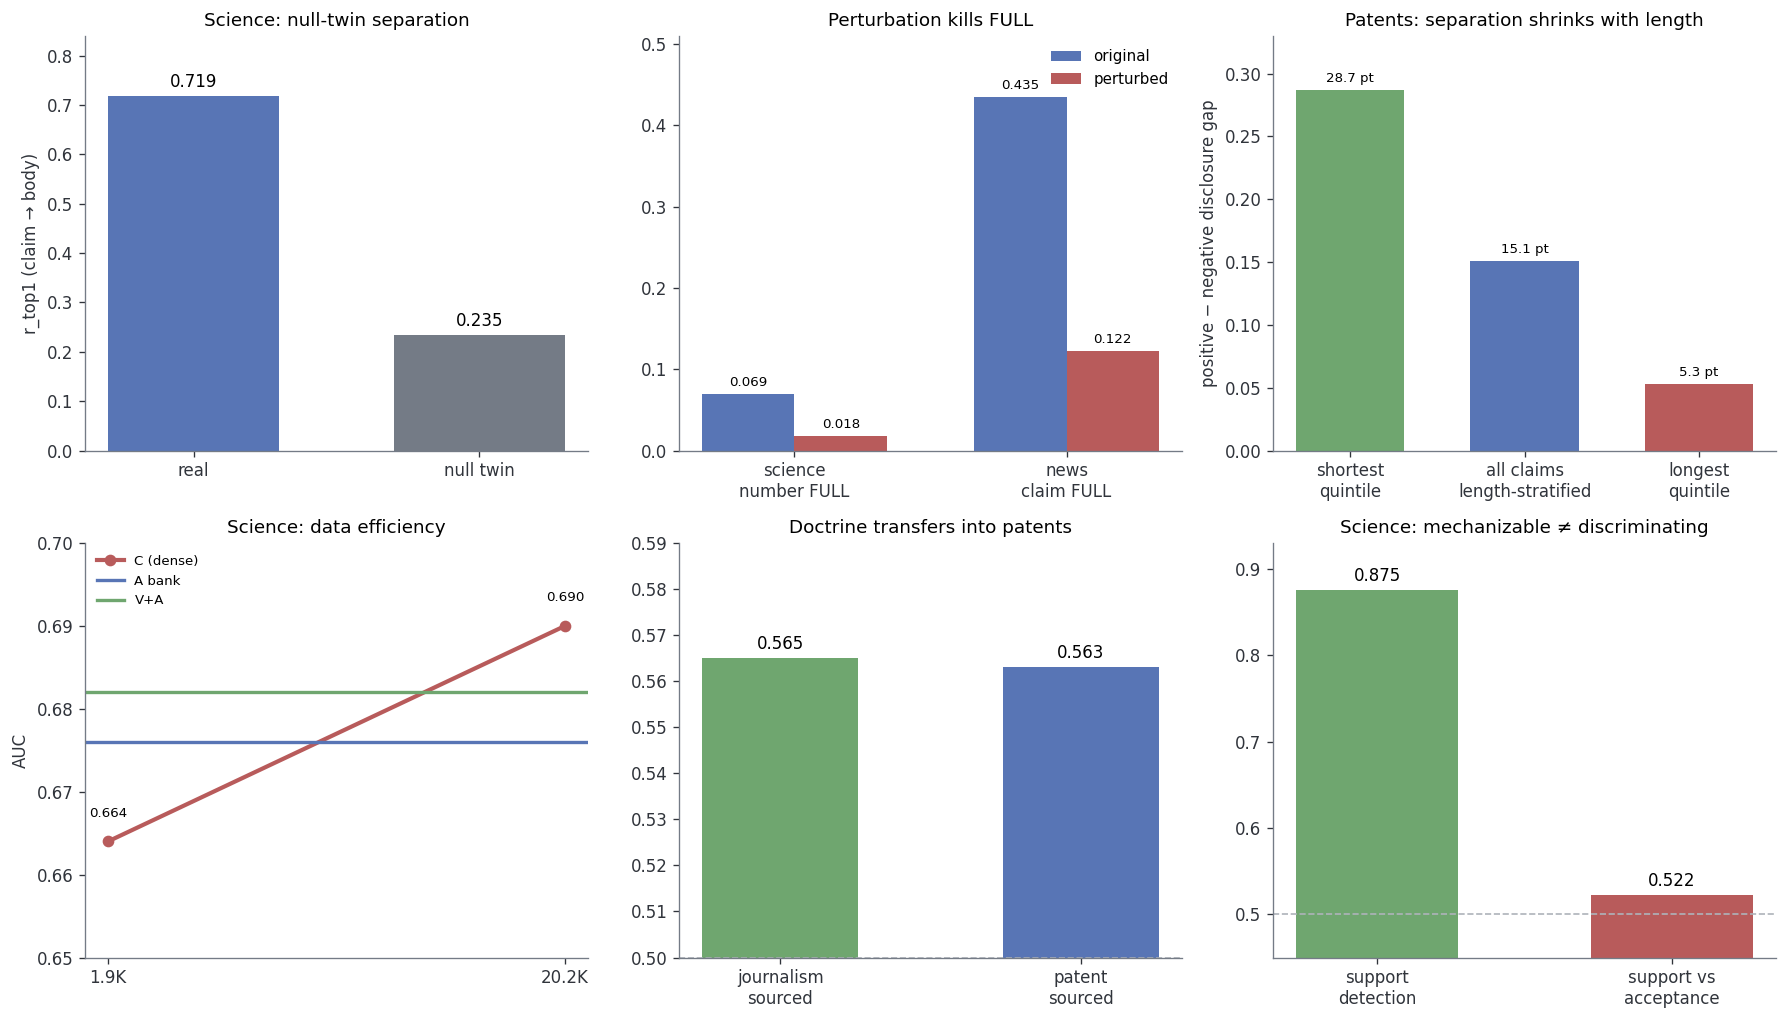

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8.6))

# 1. A real/null retrieval contrast establishes instrument sensitivity.
ax = axes[0, 0]
b = ax.bar(['real', 'null twin'], [.719, .235], color=[BLUE, MID], width=.6)
ax.bar_label(b, fmt='%.3f', padding=3)
ax.set_ylim(0, .84)
ax.set_ylabel('r_top1 (claim → body)')
ax.set_title('Science: null-twin separation', fontsize=11)

# 2. Perturbations move verdicts in the required direction in two domains.
ax = axes[0, 1]
x = np.arange(2); w = .34
b1 = ax.bar(x-w/2, [.069, .435], w, label='original', color=BLUE)
b2 = ax.bar(x+w/2, [.018, .122], w, label='perturbed', color=RED)
ax.bar_label(b1, fmt='%.3f', padding=3, fontsize=8)
ax.bar_label(b2, fmt='%.3f', padding=3, fontsize=8)
ax.set_xticks(x, ['science\nnumber FULL', 'news\nclaim FULL'])
ax.set_ylim(0, .51)
ax.set_title('Perturbation kills FULL', fontsize=11)
ax.legend(frameon=False, fontsize=9)

# 3. Only reported patent length strata are shown—no interpolated middle values.
ax = axes[0, 2]
gap_labels = ['shortest\nquintile', 'all claims\nlength-stratified', 'longest\nquintile']
gaps = [.287, .151, .053]
b = ax.bar(gap_labels, gaps, color=[GREEN, BLUE, RED], width=.62)
ax.bar_label(b, labels=[f'{100*v:.1f} pt' for v in gaps], padding=3, fontsize=8)
ax.set_ylim(0, .33)
ax.set_ylabel('positive − negative disclosure gap')
ax.set_title('Patents: separation shrinks with length', fontsize=11)

# 4. Dense needs roughly 10× as much labeled data to barely clear articulation.
ax = axes[1, 0]
train_k = np.array([1.9, 20.2])
ax.plot(train_k, [.664, .690], marker='o', lw=2.5, color=RED, label='C (dense)')
ax.axhline(.676, color=BLUE, lw=2, label='A bank')
ax.axhline(.682, color=GREEN, lw=2, label='V+A')
for x0, y0 in zip(train_k, [.664, .690]):
    ax.text(x0, y0+.003, f'{y0:.3f}', ha='center', fontsize=8)
ax.set_xticks(train_k, ['1.9K', '20.2K'])
ax.set_ylim(.65, .70)
ax.set_ylabel('AUC')
ax.set_title('Science: data efficiency', fontsize=11)
ax.legend(frameon=False, fontsize=8)

# 5. Domain of origin barely matters for patent-matching doctrine.
ax = axes[1, 1]
b = ax.bar(['journalism\nsourced', 'patent\nsourced'], [.565, .563],
           color=[GREEN, BLUE], width=.52)
ax.bar_label(b, fmt='%.3f', padding=3)
ax.axhline(.5, ls='--', color='#AEB3BA', lw=1)
ax.set_ylim(.5, .59)
ax.set_title('Doctrine transfers into patents', fontsize=11)

# 6. A verifier can work and still fail to discriminate an institutional outcome.
ax = axes[1, 2]
b = ax.bar(['support\ndetection', 'support vs\nacceptance'], [.875, .522],
           color=[GREEN, RED], width=.55)
ax.bar_label(b, fmt='%.3f', padding=3)
ax.axhline(.5, ls='--', color='#AEB3BA', lw=1)
ax.set_ylim(.45, .93)
ax.set_title('Science: mechanizable ≠ discriminating', fontsize=11)

plt.tight_layout()

### Outcome transport and patent forensics

The next two figures unpack the summary. The News chart distinguishes pooled fit from publisher transport. The patent chart distinguishes a genuine scaling gain from the retracted selection-flattered stratum and shows the main task/label constraints.

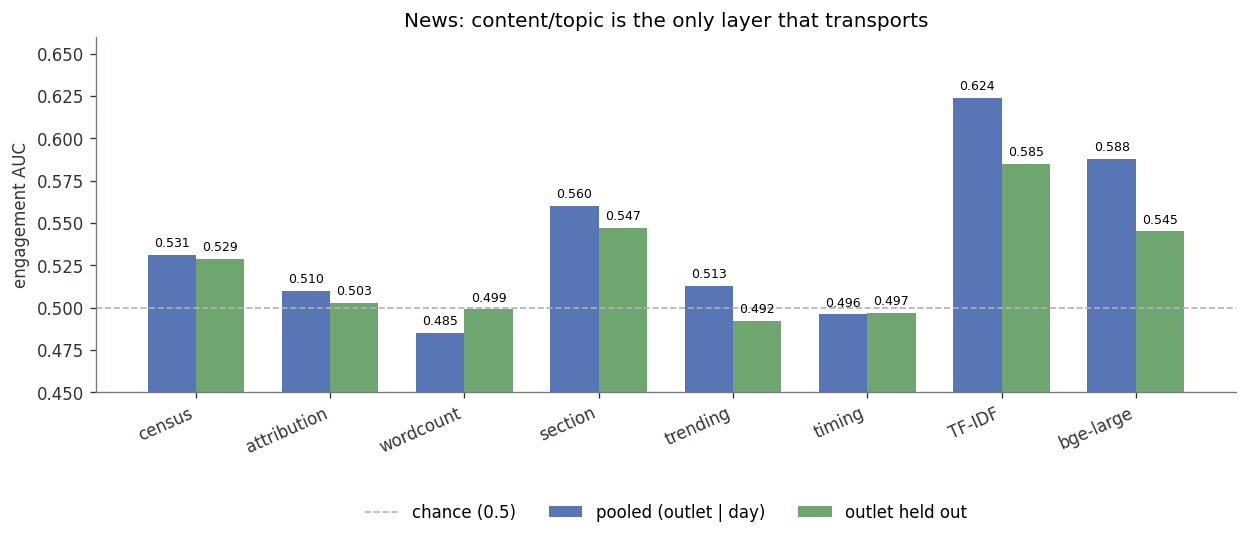

In [9]:
news_plot = news.dropna().copy()
short = ['census', 'attribution', 'wordcount', 'section', 'trending',
         'timing', 'TF-IDF', 'bge-large']
x = np.arange(len(news_plot)); w = .36

fig, ax = plt.subplots(figsize=(10.5, 4.8))
b1 = ax.bar(x-w/2, news_plot['pooled(outlet|day)'], w, color=BLUE,
            label='pooled (outlet | day)')
b2 = ax.bar(x+w/2, news_plot['outlet-held-out'], w, color=GREEN,
            label='outlet held out')
ax.axhline(.5, color='#AEB3BA', lw=1, ls='--', label='chance (0.5)')
ax.bar_label(b1, fmt='%.3f', padding=3, fontsize=7.5)
ax.bar_label(b2, fmt='%.3f', padding=3, fontsize=7.5)
ax.set_xticks(x, short, rotation=24, ha='right')
ax.set_ylim(.45, .66)
ax.set_ylabel('engagement AUC')
ax.set_title('News: content/topic is the only layer that transports')
ax.legend(ncol=3, frameon=False, loc='upper center', bbox_to_anchor=(.5, -.27))
plt.tight_layout()

/var/folders/xh/qnyq7yzj0r328_7hnb7pgxth0000gp/T/ipykernel_56455/1481824340.py:37: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


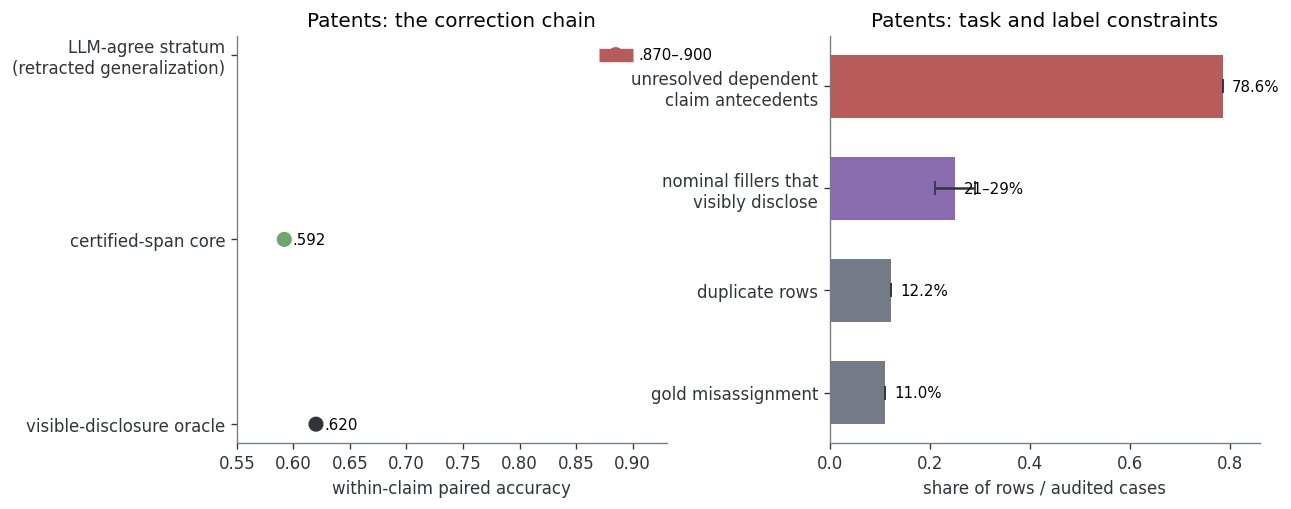

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4), gridspec_kw={'wspace': .38})

# Correction chain: plot the original claim as an interval because only a range was reported.
ax = axes[0]
labels = ['LLM-agree stratum\n(retracted generalization)',
          'certified-span core', 'visible-disclosure oracle']
y = np.arange(3)
ax.hlines(0, .870, .900, color=RED, lw=8)
ax.scatter([.885, .592, .620], y, color=[RED, GREEN, INK], s=65, zorder=3)
ax.text(.905, 0, '.870–.900', va='center', fontsize=9)
ax.text(.599, 1, '.592', va='center', fontsize=9)
ax.text(.627, 2, '.620', va='center', fontsize=9)
ax.set_yticks(y, labels)
ax.invert_yaxis()
ax.set_xlim(.55, .93)
ax.set_xlabel('within-claim paired accuracy')
ax.set_title('Patents: the correction chain')

# These are separate audit rates, not components of one partition.
ax = axes[1]
audit_labels = ['unresolved dependent\nclaim antecedents',
                'nominal fillers that\nvisibly disclose',
                'duplicate rows', 'gold misassignment']
mid = np.array([.786, .250, .122, .110])
err = np.array([0, .040, 0, 0])
y = np.arange(4)
ax.barh(y, mid, color=[RED, '#8A6BB0', MID, MID], height=.62)
ax.errorbar(mid, y, xerr=err, fmt='none', ecolor=INK, capsize=4, lw=1.5)
for yi, value, delta in zip(y, mid, err):
    label = f'{100*(value-delta):.0f}–{100*(value+delta):.0f}%' if delta else f'{100*value:.1f}%'
    ax.text(value+.018, yi, label, va='center', fontsize=9)
ax.set_yticks(y, audit_labels)
ax.invert_yaxis()
ax.set_xlim(0, .86)
ax.set_xlabel('share of rows / audited cases')
ax.set_title('Patents: task and label constraints')
plt.tight_layout()

**Findings from the expanded views.**

- **News:** dense TF-IDF is the only layer that remains clearly above chance under outlet holdout (.585); sourcing and attribution stay near chance even though corruption controls work.
- **Science:** the verifier separates real from null evidence and reacts to perturbations, but support barely predicts acceptance. The alive rubric bank (.687) essentially reaches the dense ceiling (.690), with much less labeled data.
- **Patents:** the 12b doctrine bank (.594) is within .026 of the visible-disclosure oracle (.620). The earlier .87–.90 result was selection-flattered; unresolved antecedents and contaminated nominal negatives now dominate the error budget.

## 3.4 Patent retrieval process — embedded HTML

This schematic separates **candidate retrieval**, **within-document localization**, and **verification**. Counts describe the study design; the query and passage text are illustrative. Expand the notes below the flow to see where the evaluation controls enter.

In [11]:
display(HTML(r"""
<style>
.patent-flow { --navy:#24364b; --blue:#5875B5; --green:#6FA66F; --red:#B85B5B;
  --line:#d9dde3; --muted:#67717e; font-family:Inter,ui-sans-serif,system-ui,sans-serif;
  color:#27313d; border:1px solid var(--line); border-radius:16px; padding:22px;
  background:linear-gradient(145deg,#fff,#f7f8fa); box-shadow:0 8px 28px #27313d12; }
.patent-flow * { box-sizing:border-box; }
.pf-head { display:flex; justify-content:space-between; gap:18px; align-items:flex-start; margin-bottom:18px; }
.pf-kicker { color:var(--blue); font-size:12px; font-weight:800; letter-spacing:.09em; text-transform:uppercase; }
.pf-head h3 { margin:4px 0 3px; font-size:22px; color:var(--navy); }
.pf-sub { color:var(--muted); font-size:13px; }
.pf-badge { white-space:nowrap; background:#e9eef8; color:#39547f; border-radius:999px;
  padding:7px 11px; font-weight:700; font-size:12px; }
.pf-grid { display:grid; grid-template-columns:1fr 28px 1fr 28px 1fr 28px 1fr; align-items:stretch; }
.pf-stage { background:white; border:1px solid var(--line); border-radius:12px; padding:14px; min-height:174px; }
.pf-num { width:27px; height:27px; border-radius:50%; display:grid; place-items:center;
  background:var(--navy); color:white; font-weight:800; font-size:13px; margin-bottom:10px; }
.pf-stage h4 { margin:0 0 8px; color:var(--navy); font-size:15px; }
.pf-stage p { font-size:12.5px; line-height:1.45; }
.pf-arrow { display:grid; place-items:center; color:#9ca4ae; font-size:24px; }
.pf-query { border-left:4px solid var(--blue); background:#f4f7fc; padding:9px; border-radius:7px;
  font:11.5px/1.4 ui-monospace,SFMono-Regular,Menlo,monospace; }
.pf-docs { display:flex; flex-wrap:wrap; gap:4px; margin:10px 0; }
.pf-doc { width:24px; height:32px; border:1px solid #9ca8b6; border-radius:3px; background:#f4f6f8;
  display:grid; place-items:center; font-size:9px; color:#65707c; }
.pf-doc.gold { border:2px solid var(--green); background:#edf7ed; color:#376d3d; }
.pf-span { border-left:3px solid var(--green); padding:5px 7px; background:#f0f7f0; margin:5px 0; font-size:11px; }
.pf-span.dim { border-color:#c8cdd3; background:#f5f6f7; color:#848b94; }
.pf-verdict { display:grid; grid-template-columns:1fr auto; gap:5px; font-size:11px; margin:6px 0; }
.pf-pill { border-radius:999px; padding:2px 7px; font-weight:800; }
.pf-yes { background:#e5f2e5; color:#39713f; } .pf-no { background:#f5e7e7; color:#8f4242; }
.pf-controls { display:grid; grid-template-columns:repeat(3,1fr); gap:9px; margin-top:15px; }
.pf-control { border-top:3px solid var(--blue); background:#f3f5f8; border-radius:8px; padding:10px; font-size:12px; }
.pf-control strong { display:block; color:var(--navy); margin-bottom:3px; }
.pf-notes details { background:white; border:1px solid var(--line); border-radius:8px; margin-top:7px; padding:9px 11px; }
.pf-notes summary { cursor:pointer; font-weight:700; font-size:12.5px; color:var(--navy); }
.pf-notes p { color:var(--muted); font-size:12px; margin:8px 0 2px; }
@media (max-width:900px) { .pf-grid { grid-template-columns:1fr; } .pf-arrow { transform:rotate(90deg); height:28px; }
  .pf-controls { grid-template-columns:1fr; } .pf-head { flex-direction:column; } }
</style>
<div class="patent-flow">
  <div class="pf-head">
    <div><div class="pf-kicker">Patents · retrieval + verification</div>
      <h3>From one claim element to an auditable verdict</h3>
      <div class="pf-sub">Examiner labels enter at evaluation only—not candidate generation or judging.</div>
    </div>
    <div class="pf-badge">59,937 claims · K=8 · 479,420 judged refs</div>
  </div>
  <div class="pf-grid">
    <section class="pf-stage"><div class="pf-num">1</div><h4>Atomic claim element</h4>
      <div class="pf-query">“a controller configured to adapt a transmission parameter in response to channel state …”</div>
      <p>The element becomes the query. Unresolved dependent-claim antecedents are retained as an audit flag.</p>
    </section><div class="pf-arrow">→</div>
    <section class="pf-stage"><div class="pf-num">2</div><h4>Retrieve K=8 documents</h4>
      <p>Mix one examiner-cited reference with seven same-CPC FAISS candidates.</p>
      <div class="pf-docs"><span class="pf-doc">R1</span><span class="pf-doc">R2</span><span class="pf-doc gold">R3</span><span class="pf-doc">R4</span><span class="pf-doc">R5</span><span class="pf-doc">R6</span><span class="pf-doc">R7</span><span class="pf-doc">R8</span></div>
      <p><b>Shuffle before judging</b> to remove the historical last-slot leak.</p>
    </section><div class="pf-arrow">→</div>
    <section class="pf-stage"><div class="pf-num">3</div><h4>Localize evidence</h4>
      <p>Search inside each candidate and return verbatim passages before judging disclosure.</p>
      <div class="pf-span dim">background passage …</div><div class="pf-span">candidate evidence span …</div><div class="pf-span dim">implementation detail …</div>
    </section><div class="pf-arrow">→</div>
    <section class="pf-stage"><div class="pf-num">4</div><h4>Verify each candidate</h4>
      <div class="pf-verdict"><span>R3 · grounded span</span><span class="pf-pill pf-yes">DISCLOSES</span></div>
      <div class="pf-verdict"><span>R1 · related language</span><span class="pf-pill pf-no">NO</span></div>
      <div class="pf-verdict"><span>R2 · missing limitation</span><span class="pf-pill pf-no">NO</span></div>
      <p>Store <code>{spans, discloses, vreason}</code>, then evaluate gold vs filler.</p>
    </section>
  </div>
  <div class="pf-controls">
    <div class="pf-control"><strong>Hard candidates</strong>Same-CPC fillers are topically related rather than random negatives.</div>
    <div class="pf-control"><strong>Leakage control</strong>Shuffle candidate order and group evaluation folds by application.</div>
    <div class="pf-control"><strong>Grounding control</strong>Require verbatim returned spans; ~97.6% passed grounding.</div>
  </div>
  <div class="pf-notes">
    <details><summary>Why can a filler still disclose?</summary><p>Examiner citations are incomplete labels: 21–29% of sampled fillers visibly disclose the element, contaminating nominal negatives.</p></details>
    <details><summary>Why is cross-document retrieval the remaining lever?</summary><p>For 99% of tie-probe claims, no fully disclosing paragraph existed anywhere in the cited document. The next opportunity is often §103 combination evidence across documents.</p></details>
  </div>
</div>
"""))

---
# 4 · Cross-domain synthesis

| | Journalism | Peer review | Patents |
|---|---|---|---|
| claim extraction | solved (head→claims) | solved (abstract→typed claims) | given (claim elements; antecedent gap) |
| verification-given-evidence | works (planted 73–87%) | works (self-detect .807, perturb-sensitive) | works to the **visibility ceiling** (.59 vs oracle .62) |
| what caps it | corpus has no falsity variance | substantiation universal upstream | interpretive disclosure (47%) + negative contamination (21–29%) |
| outcome relevance of matching | ~0 (upstream gate; crowd buys content) | ~0 for accept (gate); novelty axis inverts gate vs crowd | matching **is** the outcome; +15.1pt separation, V .601/A .623 |
| what actually predicts the outcome | dense topic .62/.585 (desk ≈ half) | A-bank .687 ≈ dense ceiling .690 (T̂≈0) | element-matching doctrine, at ceiling; cross-doc retrieval is the lever |
| identity confound controlled | outlet (.672 → by-construction .4997) | venue (.819 → ICLR-only) | app-grouped folds; position shuffle |

**The three laws this program keeps rediscovering:**
1. **The upstream-gate law.** Professional-integrity claim metrics are selection gates enforced *before* the observed sample exists — causally vital, statistically dead. Planted controls are the only way to prove the instrument isn't broken when the corpus has no variance.
2. **Instrument before construct.** Every dramatic number in this thread that later died — news census .689, gold-bib .799, patents .87–.90, the pilot news y itself — died to an instrument/label audit, not to a better model. The three-step (validity controls → confound decomposition → honest labels) is worth more AUC than any model upgrade.
3. **Matching is solved down to the tacit core.** Given clean, machine-visible evidence, cheap articulated doctrine matches claims about as well as anything — frontier holistic judges and trained retrievers do *worse* than 80 structured criteria + logistic. What remains unsolved is upstream (retrieval/candidate quality, label noise) and at the very bottom (graded/interpretive disclosure; taste in what counts as "the same claim").

**Open levers (ranked, all need sign-off):** patents examiner-testified negatives from OA text (fixes filler contamination without circularity); peer-review citation-y full VAT row (gate-vs-crowd at row level); news news-values LLM bank (is the within-desk dense residual articulable?); patents cross-doc §103 retrieval.

## 4.1 One plot, three domains

`V` is the direct claim verifier or holistic judge; `V+A` is the strongest articulated layer; `C` is the best content or machine-visible ceiling. For News and Science the target is the institutional outcome; for Patents, matching itself is the target. Thus the patent values are within-claim paired accuracy while the other two are AUC—compare the **within-domain gaps**, not absolute heights across domains.

| domain | V | V+A | C |
|---|---|---|---|
| News | claim support | sourcing census | dense TF-IDF content |
| Science | FULL-verdict stack | alive-50 rubric bank | dense, 20.2K train |
| Patents | holistic GLM judge | doctrine bank @12b | visible-disclosure oracle |

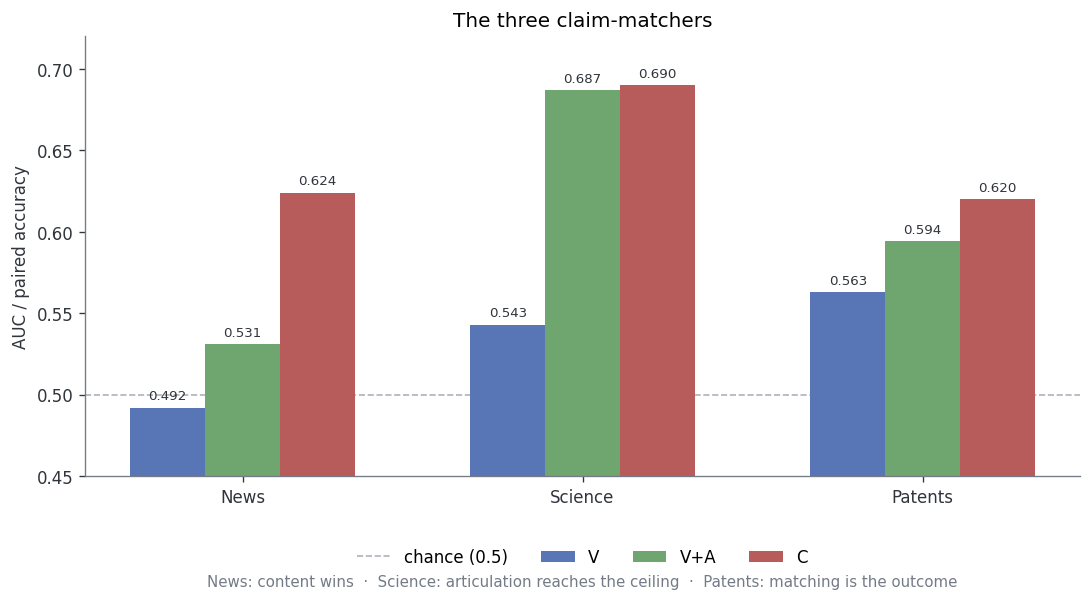

In [12]:
domains = ['News', 'Science', 'Patents']
v = np.array([.492, .543, .563])
va = np.array([.531, .687, .594])
c = np.array([.624, .690, .620])

x = np.arange(len(domains))
w = .22
fig, ax = plt.subplots(figsize=(9.2, 5.2))
b_v = ax.bar(x - w, v, w, color=BLUE, label='V')
b_va = ax.bar(x, va, w, color=GREEN, label='V+A')
b_c = ax.bar(x + w, c, w, color=RED, label='C')

ax.axhline(.5, color='#AEB3BA', lw=1, ls='--', zorder=0, label='chance (0.5)')
for bars in [b_v, b_va, b_c]:
    ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=8, color=INK)

ax.set_xticks(x, domains)
ax.set_ylim(.45, .72)
ax.set_ylabel('AUC / paired accuracy')
ax.set_title('The three claim-matchers')
ax.legend(ncol=4, frameon=False, loc='upper center', bbox_to_anchor=(.5, -.13))
ax.text(.5, -.25,
        'News: content wins  ·  Science: articulation reaches the ceiling  ·  Patents: matching is the outcome',
        transform=ax.transAxes, ha='center', color=MID, fontsize=9)
plt.tight_layout()

**Reading the gaps.** News has a **+.093 content advantage** over the strongest articulated craft layer: crowd engagement follows story/topic more than sourcing quality. Science has a **+.003 residual** between the alive rubric bank and the dense ceiling: the abstract-level acceptance signal is almost fully articulable, while direct claim verification remains upstream-gated. Patents has a **+.026 residual** between the doctrine bank and the machine-visible oracle: matching is close to its observable ceiling, leaving cross-document retrieval, interpretive disclosure, and contaminated negatives as the main bottlenecks.

---
## Artifact index

**Journalism** (sk3): `outputs/multi_y_news/{news_vat_v2.json, news_trend_decomp.json, doc_metrics_v2*.csv, embeds_v2.npz}`, `outputs/attrib_adequacy/`, `outputs/churn_check/results_scale.csv`, `outputs/planted_news/`; scripts `methods/claim_verification/run_{news_vat_v2,news_trend_decomp,attrib_adequacy,churn_scale,planted_news,multi_y_news}.py`.

**Peer review** (sk3): `datasets/peer-review/peer_review_scores_iclr.npz`, `notebooks/data/{peer_review_va.json, peer_review_dense.json}`, `outputs/claimverify_paper/`, `outputs/a_bank_audit/{gepa_revive_report.json, peer_review_revived.npz}`; scripts `datasets/peer-review/{score_va_gemma,aggregate_va,dense_baseline,gepa_revive_dead}.py`, `methods/claim_verification/{paper_adapter,run_paper_pilot,run_graded_ft,run_citation_race}.py`.

**Patents** (sk3): `datasets/patents/processed/option3_claims_gemma_scale.jsonl`, `datasets/claim-matching/testbed/pair_testbed.jsonl`, `claim_matching_bank.jsonl`, `outputs/claim_matching/`, `notebooks/data/patents_va_features.csv`, `datasets/patents/2026-07-10__evidence_aware_judge_ws3.md`; scripts `scripts/claim_matching_*.py`, `datasets/patents/audit_regroup_va.py`.

Memory: `project_claim_verification_multi_y`, `project_peer_review_va`, `project_claim_matching_vat`, `project_patents_prior_art_pipeline`, `project_a_bank_degeneracy_audit`.